In [5]:
import polars as pl
from pathlib import Path

In [3]:
PROJECT_ROOT = Path.cwd().parent 
data = pl.read_parquet(PROJECT_ROOT / "data/raw/20250811_bgg.parquet")

--- Statistics ---
shape: (9, 3)
┌────────────┬─────────────┬─────────────┐
│ statistic  ┆ min_players ┆ max_players │
│ ---        ┆ ---         ┆ ---         │
│ str        ┆ f64         ┆ f64         │
╞════════════╪═════════════╪═════════════╡
│ count      ┆ 88465.0     ┆ 88465.0     │
│ null_count ┆ 0.0         ┆ 0.0         │
│ mean       ┆ 2.010558    ┆ 6.140361    │
│ std        ┆ 0.860119    ┆ 53.580823   │
│ min        ┆ 0.0         ┆ 0.0         │
│ 25%        ┆ 2.0         ┆ 2.0         │
│ 50%        ┆ 2.0         ┆ 4.0         │
│ 75%        ┆ 2.0         ┆ 6.0         │
│ max        ┆ 50.0        ┆ 11299.0     │
└────────────┴─────────────┴─────────────┘

--- Percentiles for Max Players ---
shape: (1, 4)
┌────────┬────────┬────────┬──────────────┐
│ 90th % ┆ 95th % ┆ 99th % ┆ Absolute Max │
│ ---    ┆ ---    ┆ ---    ┆ ---          │
│ f64    ┆ f64    ┆ f64    ┆ i64          │
╞════════╪════════╪════════╪══════════════╡
│ 8.0    ┆ 10.0   ┆ 99.0   ┆ 11299        │
└──────

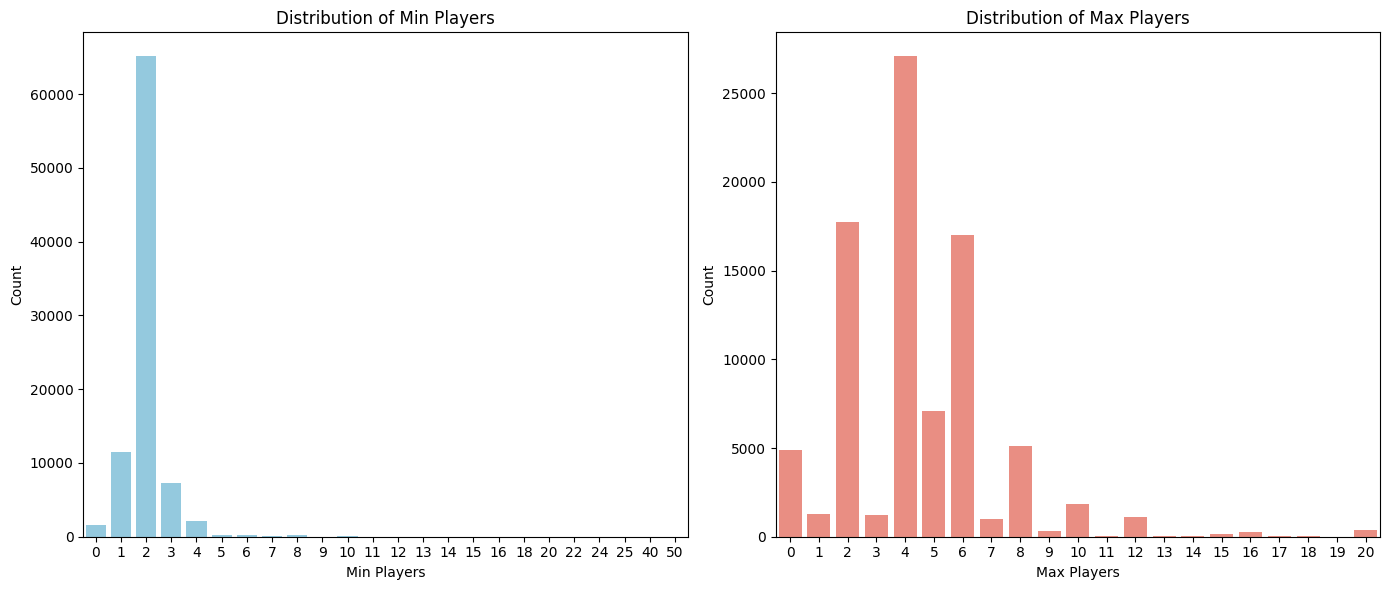

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_player_distribution(df: pl.DataFrame, min_col="min_players", max_col="max_players"):
    df = df.with_columns([
        pl.col(min_col).cast(pl.Int64, strict=False),
        pl.col(max_col).cast(pl.Int64, strict=False)
    ])

    df = df.drop_nulls(subset=[min_col, max_col])

    print("--- Statistics ---")
    print(df.select([min_col, max_col]).describe())
    
    quantiles = df.select([
        pl.col(max_col).quantile(0.90).alias("90th %"),
        pl.col(max_col).quantile(0.95).alias("95th %"),
        pl.col(max_col).quantile(0.99).alias("99th %"),
        pl.col(max_col).max().alias("Absolute Max")
    ])
    print("\n--- Percentiles for Max Players ---")
    print(quantiles)

    print("\n--- Most Common Max Player Counts ---")
    print(df[max_col].value_counts().sort("count", descending=True).head(10))

    pdf = df.select([min_col, max_col]).to_pandas()

    _, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.countplot(data=pdf, x=min_col, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of Min Players')
    axes[0].set_xlabel('Min Players')
    axes[0].set_ylabel('Count')
    
    sns.countplot(data=pdf[pdf[max_col] <= 20], x=max_col, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of Max Players')
    axes[1].set_xlabel('Max Players')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

analyze_player_distribution(df=data)